In [3]:
# importing liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Added SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [4]:
# loading the data set
data1=pd.read_csv("client_train.csv")
data2=pd.read_csv("invoice_train.csv")

data3=pd.read_csv("client_test.csv")
data4=pd.read_csv("invoice_test.csv")


In [5]:
# merging datasets
df1=pd.merge(data1,data2,on='client_id',how='left')
df2=pd.merge(data3,data4,on='client_id',how='left')

# DATA CLEANING AND EDA

In [6]:
# train data set
df1.head()

,disrict,client_id,client_catg,region,creation_date,target,invoice_date,tarif_type,counter_number,counter_statue,...,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,60,train_Client_0,11,101,31/12/1994,0.0,2014-03-24,11.0,1335667.0,0.0,...,8.0,1.0,82.0,0.0,0.0,0.0,14302.0,14384.0,4.0,ELEC
1,60,train_Client_0,11,101,31/12/1994,0.0,2013-03-29,11.0,1335667.0,0.0,...,6.0,1.0,1200.0,184.0,0.0,0.0,12294.0,13678.0,4.0,ELEC
2,60,train_Client_0,11,101,31/12/1994,0.0,2015-03-23,11.0,1335667.0,0.0,...,8.0,1.0,123.0,0.0,0.0,0.0,14624.0,14747.0,4.0,ELEC
3,60,train_Client_0,11,101,31/12/1994,0.0,2015-07-13,11.0,1335667.0,0.0,...,8.0,1.0,102.0,0.0,0.0,0.0,14747.0,14849.0,4.0,ELEC
4,60,train_Client_0,11,101,31/12/1994,0.0,2016-11-17,11.0,1335667.0,0.0,...,9.0,1.0,572.0,0.0,0.0,0.0,15066.0,15638.0,12.0,ELEC


In [7]:
df1.describe()

,disrict,client_catg,region,target,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,568248.000000,568248.000000,568248.000000,568248.000000,446055.000000,4.460550e+05,446055.000000,446055.000000,446055.000000,446055.000000,446054.000000,446054.000000,446054.000000,446054.000000,4.460540e+05,4.460540e+05,446054.000000
mean,63.525601,11.849636,208.348587,0.074893,20.218800,1.123780e+11,0.041699,171.390346,7.314172,1.000038,404.585853,107.207553,20.338367,53.261796,1.759998e+04,1.815468e+04,27.065223
std,3.310632,5.715559,103.809317,0.263219,13.503997,1.582127e+12,0.372950,133.614385,1.359843,0.019465,565.061250,888.548733,200.932721,1099.480241,4.283474e+04,4.343304e+04,1644.127929
min,60.000000,11.000000,101.000000,0.000000,8.000000,0.000000e+00,0.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000
25%,62.000000,11.000000,103.000000,0.000000,11.000000,1.227890e+05,0.000000,5.000000,6.000000,1.000000,78.000000,0.000000,0.000000,0.000000,1.757000e+03,2.024000e+03,4.000000
50%,62.000000,11.000000,301.000000,0.000000,11.000000,4.966060e+05,0.000000,203.000000,6.000000,1.000000,269.000000,0.000000,0.000000,0.000000,7.474000e+03,7.972000e+03,4.000000
75%,63.000000,11.000000,307.000000,0.000000,40.000000,1.134305e+06,0.000000,207.000000,9.000000,1.000000,600.000000,0.000000,0.000000,0.000000,2.138900e+04,2.205600e+04,4.000000
max,69.000000,51.000000,399.000000,1.000000,45.000000,2.738110e+13,5.000000,600.000000,9.000000,10.000000,93385.000000,209952.000000,45360.000000,343568.000000,2.800280e+06,2.870972e+06,231602.000000


In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568248 entries, 0 to 568247
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   disrict               568248 non-null  int64  
 1   client_id             568248 non-null  object 
 2   client_catg           568248 non-null  int64  
 3   region                568248 non-null  int64  
 4   creation_date         568248 non-null  object 
 5   target                568248 non-null  float64
 6   invoice_date          446055 non-null  object 
 7   tarif_type            446055 non-null  float64
 8   counter_number        446055 non-null  float64
 9   counter_statue        446055 non-null  float64
 10  counter_code          446055 non-null  float64
 11  reading_remarque      446055 non-null  float64
 12  counter_coefficient   446055 non-null  float64
 13  consommation_level_1  446054 non-null  float64
 14  consommation_level_2  446054 non-null  float64
 15  

In [9]:
# duplicated values
df1.duplicated().sum()

np.int64(0)

In [10]:
df1.drop_duplicates(inplace=True)

In [11]:
# null values
df1.isnull().sum()/len(df1)*100

,0
disrict,0.000000
client_id,0.000000
client_catg,0.000000
region,0.000000
creation_date,0.000000
target,0.000000
invoice_date,21.503463
tarif_type,21.503463
counter_number,21.503463
counter_statue,21.503463


In [12]:
numerical_col=df1.select_dtypes(int,float).columns
categorical_col=df1.select_dtypes(object).columns
numerical_col,categorical_col

(Index(['disrict', 'client_catg', 'region'], dtype='object'),
 Index(['client_id', 'creation_date', 'invoice_date', 'counter_type'], dtype='object'))

In [13]:
# Convert dates
df1['creation_date'] = pd.to_datetime(df1['creation_date'])
df1['invoice_date'] = pd.to_datetime(df1['invoice_date'])

# Extract date features
df1['creation_year'] = df1['creation_date'].dt.year
df1['creation_month'] = df1['creation_date'].dt.month

df1['invoice_year'] = df1['invoice_date'].dt.year
df1['invoice_month'] = df1['invoice_date'].dt.month
df1['invoice_dayofweek'] = df1['invoice_date'].dt.dayofweek

In [14]:
# feature engeneering
df1['total_consumption'] = (
    df1['consommation_level_1'] +
    df1['consommation_level_2'] +
    df1['consommation_level_3'] +
    df1['consommation_level_4']
)


df1['level1_ratio'] = (
    df1['consommation_level_1'] /
    df1['total_consumption']
)

df1['index_difference'] = (
    df1['new_index'] -
    df1['old_index']
)
df1['avg_monthly_consumption'] = (
    df1['total_consumption'] /
    df1['months_number']
)
df1['consumption_per_counter'] = (
    df1['total_consumption'] /
    df1['counter_coefficient']
)
df1['invoice_date'] = pd.to_datetime(df1['invoice_date'])

df1['invoice_year_month'] = (
    df1['invoice_date'].dt.to_period('M')
)

# VISUALIZATION

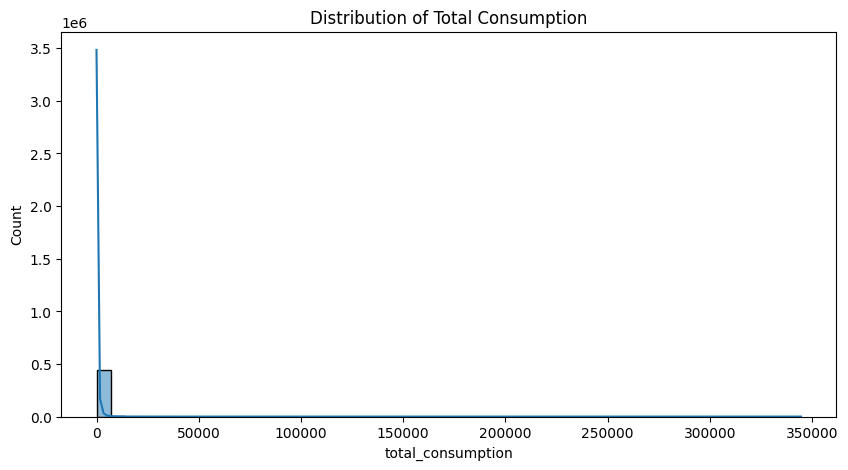

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df1['total_consumption'], bins=50, kde=True)
plt.title('Distribution of Total Consumption')
plt.show()

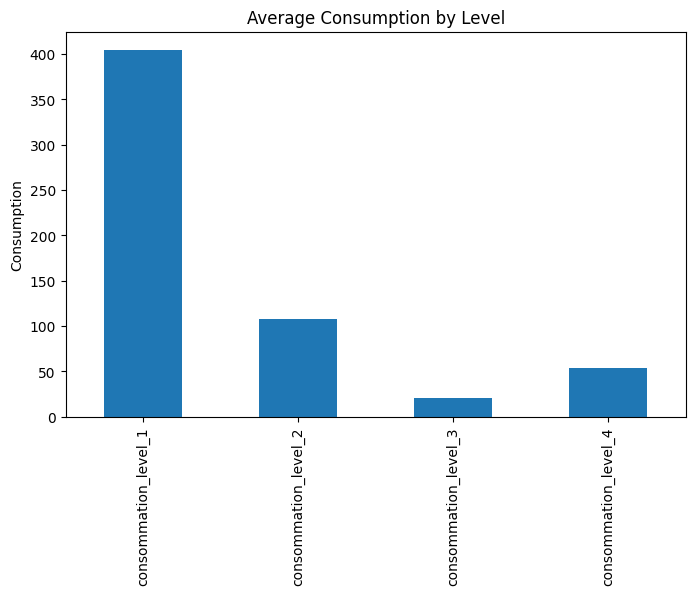

In [16]:
consumption_cols = [
    'consommation_level_1',
    'consommation_level_2',
    'consommation_level_3',
    'consommation_level_4'
]

df1[consumption_cols].mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Consumption by Level')
plt.ylabel('Consumption')
plt.show()

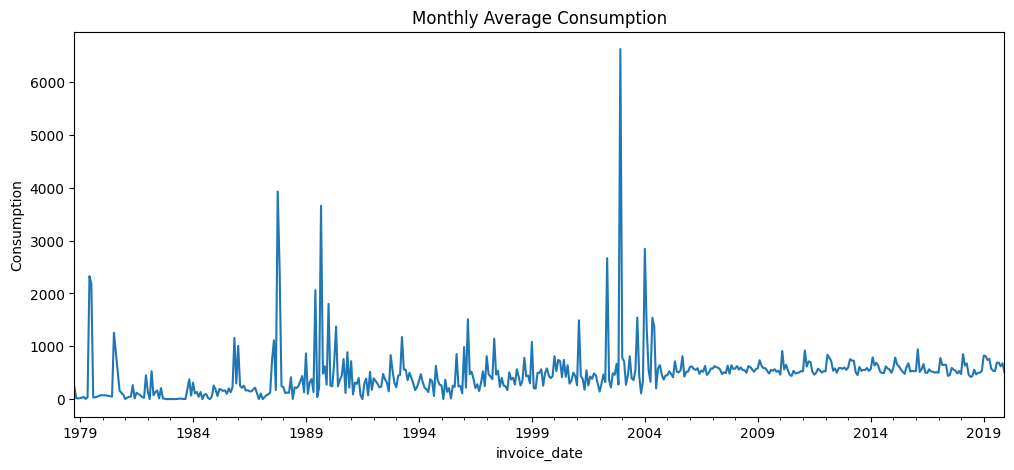

In [17]:
monthly = df1.groupby(
    df1['invoice_date'].dt.to_period('M')
)['total_consumption'].mean()

monthly.plot(figsize=(12,5))
plt.title('Monthly Average Consumption')
plt.ylabel('Consumption')
plt.show()

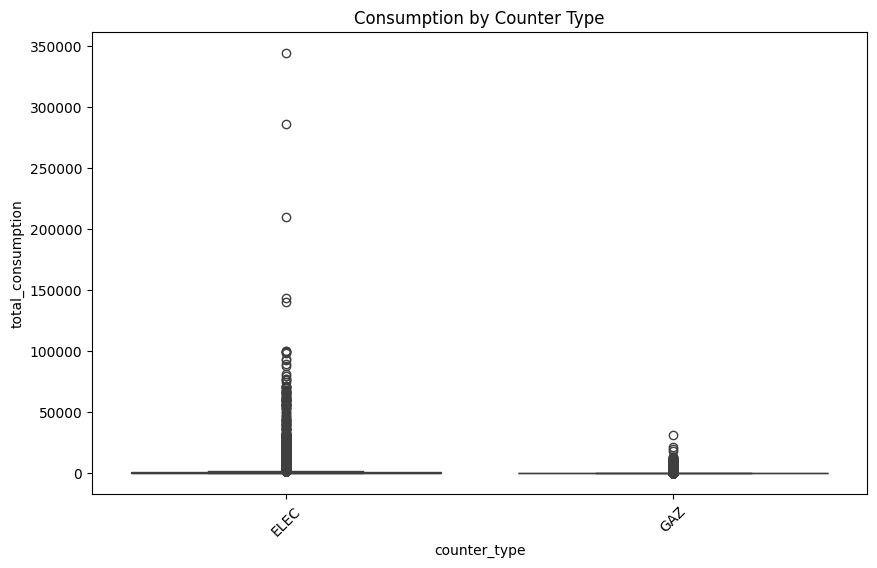

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='counter_type',
    y='total_consumption',
    data=df1
)

plt.xticks(rotation=45)
plt.title('Consumption by Counter Type')
plt.show()

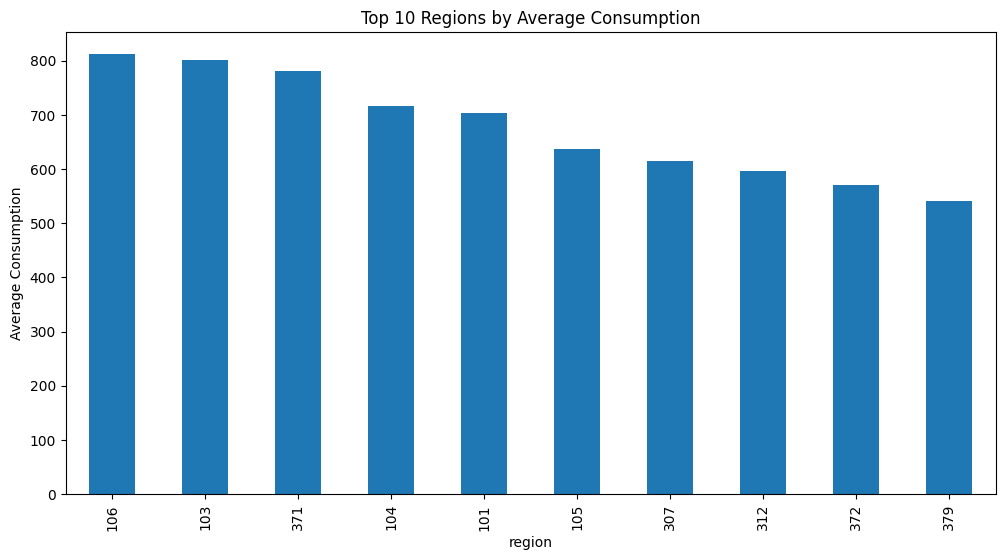

In [19]:
region_consumption = (
    df1.groupby('region')['total_consumption']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
region_consumption.plot(kind='bar')
plt.title('Top 10 Regions by Average Consumption')
plt.ylabel('Average Consumption')
plt.show()

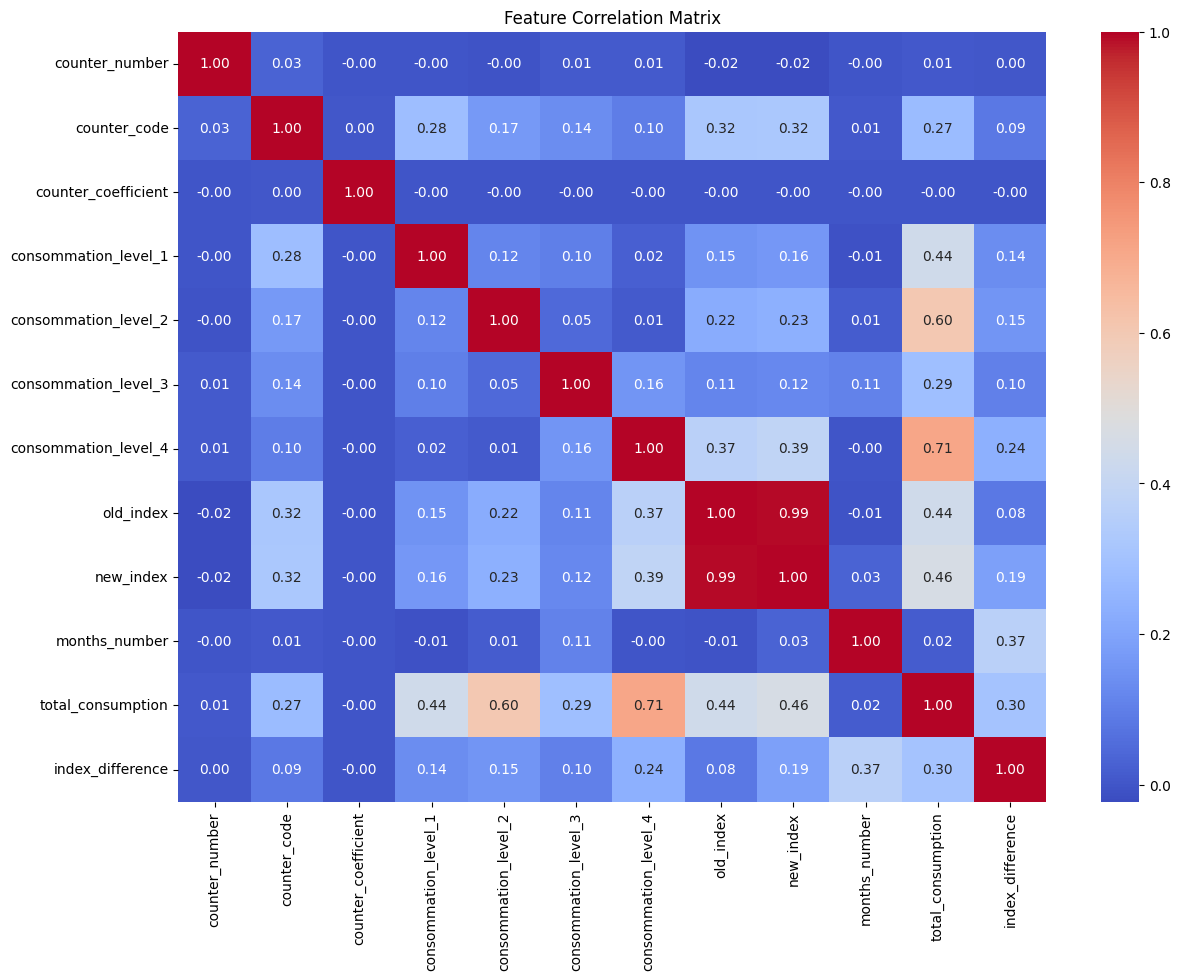

In [20]:
numeric_cols = [
    'counter_number',
    'counter_code',
    'counter_coefficient',
    'consommation_level_1',
    'consommation_level_2',
    'consommation_level_3',
    'consommation_level_4',
    'old_index',
    'new_index',
    'months_number',
    'total_consumption',
    'index_difference'
]

plt.figure(figsize=(14,10))

sns.heatmap(
    df1[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Matrix')
plt.show()

MODELLING


In [21]:
# feature and target selection
x=df1.drop(['client_id','creation_date','invoice_date','invoice_year_month','target'],axis=1)
y=df1['target']


In [22]:
x = pd.get_dummies(x,drop_first=True)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
# preprocessing

# Handle potential infinite values by replacing them with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute NaN values using SimpleImputer
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on X_train and transform both X_train and X_test
X_train = imputer.fit_transform(X_train) # X_train becomes a NumPy array here
X_test = imputer.transform(X_test) # X_test becomes a NumPy array here

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

LOGISTIC CLASSIFICATION

In [25]:
# base model
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96    105124
         1.0       0.57      0.00      0.00      8526

    accuracy                           0.92    113650
   macro avg       0.75      0.50      0.48    113650
weighted avg       0.90      0.92      0.89    113650



SVM CLASSIFICATION

DECISON TREE CLASSIFICATION

In [26]:
dt=DecisionTreeClassifier(max_depth=5)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96    105124
         1.0       0.62      0.06      0.11      8526

    accuracy                           0.93    113650
   macro avg       0.77      0.53      0.54    113650
weighted avg       0.91      0.93      0.90    113650



RANDOM FOREST CLASSIFICATION

In [27]:
rf=RandomForestClassifier(max_depth=5,n_estimators=100)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96    105124
         1.0       1.00      0.00      0.00      8526

    accuracy                           0.93    113650
   macro avg       0.96      0.50      0.48    113650
weighted avg       0.93      0.93      0.89    113650



XGBOOST

In [28]:
xg=XGBClassifier()
xg.fit(X_train,y_train)
y_pred=xg.predict(X_test)
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97    105124
         1.0       0.95      0.26      0.40      8526

    accuracy                           0.94    113650
   macro avg       0.95      0.63      0.69    113650
weighted avg       0.94      0.94      0.93    113650



MODELs EVALUATION

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

Model Performance Comparison:
                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression    0.9250     0.8985  0.9250    0.8891
1        Decision Tree    0.9319     0.9237  0.9319    0.9081
2        Random Forest    0.9297     0.9338  0.9297    0.9001
3              XGBoost    0.9433     0.9438  0.9433    0.9278


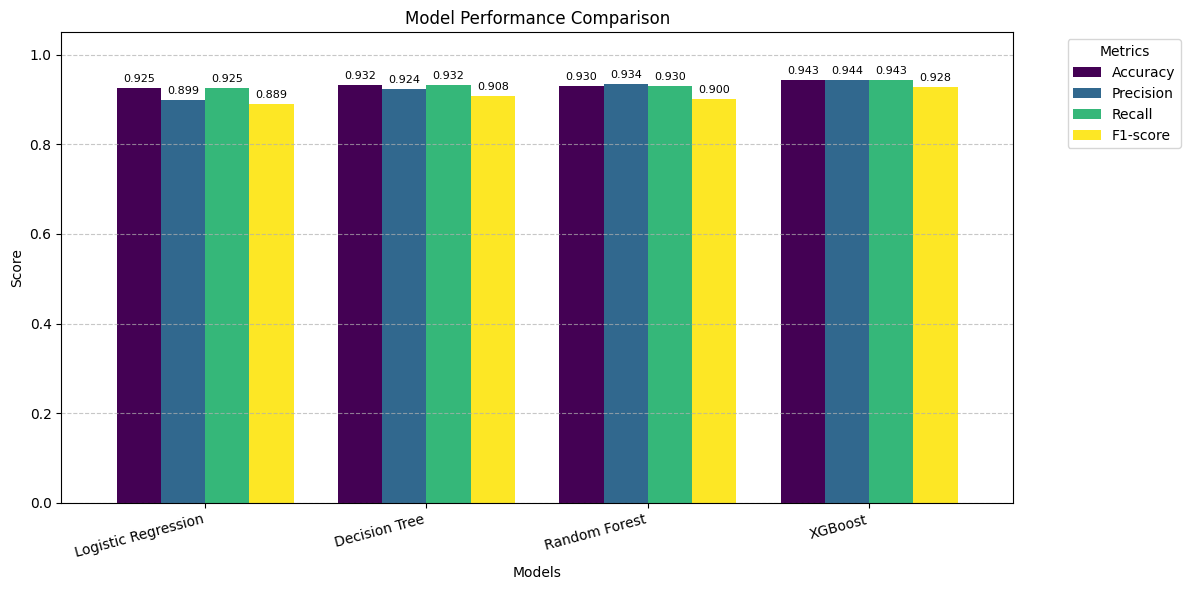

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42, max_depth=10)),
    ('Random Forest', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=10
    )),
    ('XGBoost', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_estimators=100,
        max_depth=6,
        n_jobs=-1,
        verbosity=0
    ))
]

# Store evaluation metrics
results = []

for model_name, model in models:
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-score': f1_score(y_test, y_pred, average='weighted')
    })

# Create DataFrame
results_df = pd.DataFrame(results)

print("\nModel Performance Comparison:")
print(results_df.round(4))

# Plot
ax = results_df.set_index('Model').plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8,
    colormap='viridis'
)

plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=3)

plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# TUNNING
the best performing model

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV # Added this import

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [ ]:
grid.fit(X_train, y_train)

feature importance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Get the best tuned model
best_model = grid.best_estimator_

# Get feature names
if hasattr(X_train, "columns"):
    feature_names = X_train.columns
else:
    feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]

# Get feature importances
importance = best_model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
print(feature_importance.head(15))

# Plot
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:15][::-1],
    feature_importance["Importance"][:15][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 15 Important Features (Tuned XGBoost)")

# Add labels
for index, value in enumerate(feature_importance["Importance"][:15][::-1]):
    plt.text(value, index, f"{value:.3f}", va="center")

plt.tight_layout()
plt.show()

TESTING

In [ ]:
data1=pd.read_csv("client_test.csv")
data2=pd.read_csv("invoice_test.csv")
data=pd.merge(data1,data2,on='client_id',how='left')
data